# 📘 CIFAR-10 Image Classification Learning Project
## Build and Compare **ANN vs CNN** on CIFAR-10

This notebook is designed for **students and beginners** to learn:
- How image classification works
- Why **CNN performs better than ANN**
- How architecture impacts performance
- How training strategies improve results

🎯 **Learning Goal:** Understand the complete DL pipeline by **reading the markdown + running the ready code**.

# 🧠 Problem Statement
Build an image classification model on the **CIFAR-10 dataset** using:

1. **Artificial Neural Network (ANN)**
2. **Convolutional Neural Network (CNN)**

Then compare:
- Accuracy
- Loss curves
- Generalization
- Training strategies (dropout, batch norm, augmentation)

---
### 📦 CIFAR-10 Classes
Airplane, Automobile, Bird, Cat, Deer, Dog, Frog, Horse, Ship, Truck

In [10]:
import tensorflow as tf
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.20.0


# 📥 Load Dataset
We use **CIFAR-10**, which contains **60,000 color images of size 32×32×3**.
- 50,000 training images
- 10,000 test images

In [11]:
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.cifar10.load_data()

class_names = ['airplane','automobile','bird','cat','deer',
               'dog','frog','horse','ship','truck']

print("Train shape:", x_train.shape)
print("Test shape:", x_test.shape)

Train shape: (50000, 32, 32, 3)
Test shape: (10000, 32, 32, 3)


## 🖼️ Visualize Sample Images

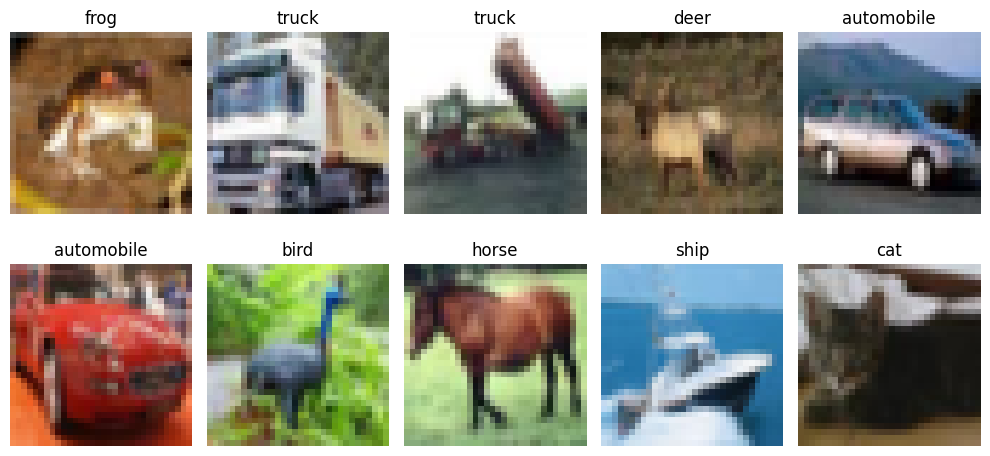

In [12]:
plt.figure(figsize=(10,5))
for i in range(10):
    plt.subplot(2,5,i+1)
    plt.imshow(x_train[i])
    plt.title(class_names[y_train[i][0]])
    plt.axis("off")
plt.tight_layout()
plt.show()

# 🧹 Preprocessing
We normalize pixel values from **0–255 → 0–1** so training becomes stable.

In [13]:
x_train_norm = x_train / 255.0
x_test_norm = x_test / 255.0

x_train_flat = x_train_norm.reshape(len(x_train_norm), -1)
x_test_flat = x_test_norm.reshape(len(x_test_norm), -1)

print("Flat x_train shape:", x_train_flat.shape)
print("Norm x_train shape:", x_train_norm.shape)

Flat x_train shape: (50000, 3072)
Norm x_train shape: (50000, 32, 32, 3)


In [14]:
x_train_norm

array([[[[0.23137255, 0.24313725, 0.24705882],
         [0.16862745, 0.18039216, 0.17647059],
         [0.19607843, 0.18823529, 0.16862745],
         ...,
         [0.61960784, 0.51764706, 0.42352941],
         [0.59607843, 0.49019608, 0.4       ],
         [0.58039216, 0.48627451, 0.40392157]],

        [[0.0627451 , 0.07843137, 0.07843137],
         [0.        , 0.        , 0.        ],
         [0.07058824, 0.03137255, 0.        ],
         ...,
         [0.48235294, 0.34509804, 0.21568627],
         [0.46666667, 0.3254902 , 0.19607843],
         [0.47843137, 0.34117647, 0.22352941]],

        [[0.09803922, 0.09411765, 0.08235294],
         [0.0627451 , 0.02745098, 0.        ],
         [0.19215686, 0.10588235, 0.03137255],
         ...,
         [0.4627451 , 0.32941176, 0.19607843],
         [0.47058824, 0.32941176, 0.19607843],
         [0.42745098, 0.28627451, 0.16470588]],

        ...,

        [[0.81568627, 0.66666667, 0.37647059],
         [0.78823529, 0.6       , 0.13333333]

# 🔹 Part 1: ANN Model
ANN treats images as **flat vectors**, so it cannot preserve spatial features.
This helps students understand **why CNN is better for images**.

In [15]:
ann_model = models.Sequential([
    layers.Dense(512, activation='relu', input_shape=(3072,)),
    layers.Dropout(0.3),
    layers.Dense(256, activation='relu'),
    layers.Dense(10, activation='softmax')
])

ann_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

ann_history = ann_model.fit(
    x_train_flat, y_train,
    epochs=10,
    validation_split=0.1,
    batch_size=64
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 8s 7ms/step - accuracy: 0.2664 - loss: 1.9931 - val_accuracy: 0.3388 - val_loss: 1.8381
Epoch 2/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.3158 - loss: 1.8705 - val_accuracy: 0.3502 - val_loss: 1.7904
Epoch 3/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.3401 - loss: 1.8070 - val_accuracy: 0.3778 - val_loss: 1.7613
Epoch 4/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.3524 - loss: 1.7800 - val_accuracy: 0.3726 - val_loss: 1.7301
Epoch 5/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.3660 - loss: 1.7451 - val_accuracy: 0.3914 - val_loss: 1.7143
Epoch 6/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.3691 - loss: 1.7319 - val_accuracy: 0.3904 - val_loss: 1.6921
Epoch 7/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.3806 - loss: 1.7082 - val_accuracy: 0.4162 - val_loss: 1.6610
Epoch 8/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.3870 - loss: 1.6947 - val_accuracy: 0.

In [16]:
ann_test_loss, ann_test_acc = ann_model.evaluate(x_test_flat, y_test)
print("ANN Test Accuracy:", ann_test_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.4232 - loss: 1.6251
ANN Test Accuracy: 0.42320001125335693


# 🔹 Part 2: CNN Model
CNN preserves **spatial relationships** using:
- Convolution layers
- Pooling
- Feature extraction
- Hierarchical learning

This is why CNN performs much better for image tasks.

In [17]:
cnn_model = models.Sequential([
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(32,32,3)),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(128, (3,3), activation='relu'),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.4),
    layers.Dense(10, activation='softmax')
])

cnn_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

cnn_history = cnn_model.fit(
    x_train_norm, y_train,
    epochs=10,
    validation_split=0.1,
    batch_size=64
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 14s 12ms/step - accuracy: 0.4682 - loss: 1.4949 - val_accuracy: 0.5298 - val_loss: 1.3142
Epoch 2/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.6027 - loss: 1.1303 - val_accuracy: 0.6042 - val_loss: 1.1039
Epoch 3/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.6674 - loss: 0.9534 - val_accuracy: 0.6922 - val_loss: 0.8846
Epoch 4/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.7046 - loss: 0.8424 - val_accuracy: 0.6156 - val_loss: 1.2171
Epoch 5/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.7374 - loss: 0.7549 - val_accuracy: 0.6694 - val_loss: 1.0315
Epoch 6/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.7639 - loss: 0.6751 - val_accuracy: 0.6756 - val_loss: 0.9454
Epoch 7/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.7884 - loss: 0.6015 - val_accuracy: 0.6934 - val_loss: 0.8968
Epoch 8/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.8055 - loss: 0.5466 - val_accuracy: 

In [18]:
cnn_test_loss, cnn_test_acc = cnn_model.evaluate(x_test_norm, y_test)
print("CNN Test Accuracy:", cnn_test_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.7004 - loss: 0.9487
CNN Test Accuracy: 0.7003999948501587


## 📈 Compare Learning Curves

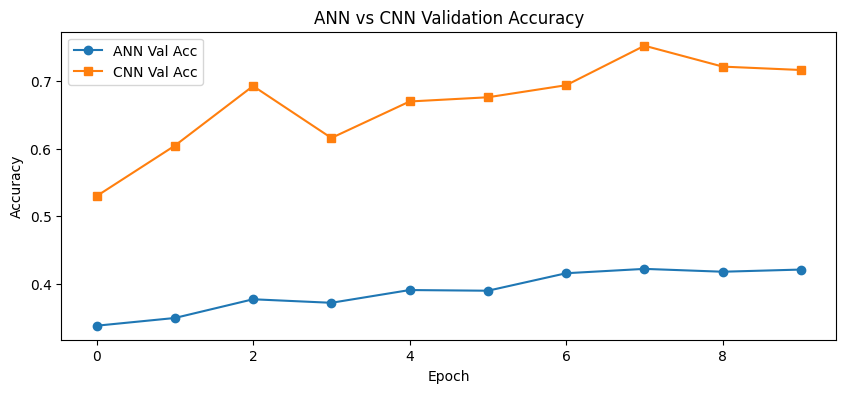

In [19]:
plt.figure(figsize=(10,4))
plt.plot(ann_history.history['val_accuracy'], label='ANN Val Acc',marker='o')
plt.plot(cnn_history.history['val_accuracy'], label='CNN Val Acc',marker='s')
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("ANN vs CNN Validation Accuracy")
plt.legend()
plt.show()

# 🚀 Training Strategy Upgrade: Data Augmentation
This strategy improves generalization by generating transformed images.

In [20]:
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1)
])

aug_cnn_model = models.Sequential([
    data_augmentation,
    layers.Conv2D(32, 3, activation='relu', input_shape=(32,32,3)),
    layers.MaxPooling2D(),
    layers.Conv2D(64, 3, activation='relu'),
    layers.MaxPooling2D(),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.4),
    layers.Dense(10, activation='softmax')
])

aug_cnn_model.compile(optimizer='adam',
                      loss='sparse_categorical_crossentropy',
                      metrics=['accuracy'])
# Suggested optional run:
# aug_history = aug_cnn_model.fit(x_train_norm, y_train, epochs=10, validation_split=0.1)

# 📊 Final Comparison Table

In [21]:
comparison = pd.DataFrame({
    "Model": ["ANN", "CNN"],
    "Test Accuracy": [ann_test_acc, cnn_test_acc]
})

comparison

,Model,Test Accuracy
0,ANN,0.4232
1,CNN,0.7004


# 🎓 Student Learning Tasks
Try these tasks after understanding the notebook:

### ✅ Beginner Tasks
1. Increase ANN layers and observe performance
2. Change CNN filters from 32→64→128
3. Increase epochs to 20
4. Add **EarlyStopping**
5. Add **data augmentation training**

In [22]:
np.unique(y_train)

array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9], dtype=uint8)

## ✅ Task 1 — Increase ANN Layers

In [23]:
from keras.layers import Dense,Dropout

deep_ann=models.Sequential()
deep_ann.add(Dense(1024,activation='relu',input_shape=(3072,)))
deep_ann.add(Dropout(0.3))

deep_ann.add(Dense(512,activation='relu'))
deep_ann.add(Dropout(0.3))

deep_ann.add(Dense(256,activation='relu'))
deep_ann.add(Dense(128,activation='relu'))
deep_ann.add(Dense(10,activation='softmax')) # As the target is (label encoded) contains 0 to 9 values

deep_ann.compile(loss='sparse_categorical_crossentropy',optimizer='Adam',metrics=['accuracy'])


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [24]:
deep_ann.summary()

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_7 (Dense)                 │ (None, 1024)           │     3,146,752 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 512)            │       524,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,837,066 (14.64 MB)

 Trainable params: 3,837,066 (14.64 MB)

 Non-trainable params: 0 (0.00 B)

In [25]:
deep_ann_history=deep_ann.fit(x_train_flat,y_train,epochs=10,validation_split=0.1,batch_size=64)

Epoch 1/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 10s 9ms/step - accuracy: 0.2492 - loss: 2.0271 - val_accuracy: 0.3110 - val_loss: 1.8750
Epoch 2/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.3156 - loss: 1.8761 - val_accuracy: 0.3506 - val_loss: 1.8004
Epoch 3/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.3345 - loss: 1.8281 - val_accuracy: 0.3742 - val_loss: 1.7874
Epoch 4/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.3440 - loss: 1.7952 - val_accuracy: 0.3840 - val_loss: 1.7317
Epoch 5/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.3565 - loss: 1.7699 - val_accuracy: 0.3906 - val_loss: 1.7100
Epoch 6/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.3681 - loss: 1.7455 - val_accuracy: 0.4052 - val_loss: 1.6959
Epoch 7/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.3776 - loss: 1.7213 - val_accuracy: 0.4036 - val_loss: 1.6788
Epoch 8/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.3785 - loss: 1.7158 - val_accuracy: 0

In [26]:
deep_ann_loss,deep_ann_accuracy=deep_ann.evaluate(x_test_flat,y_test)
print("Deep Ann Test Accuarcy: ",deep_ann_accuracy)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.4129 - loss: 1.6461
Deep Ann Test Accuarcy:  0.41290000081062317


## Observation
- Increasing ANN depth did not improve performance and resulted in slightly lower test accuracy than the baseline ANN.

## ✅ Task 2 — Scale CNN Filters 32 → 64 → 128

In [27]:
from keras.layers import Convolution2D,BatchNormalization,MaxPool2D,Flatten

scaled_cnn=models.Sequential()
scaled_cnn.add(Convolution2D(32,kernel_size=(3,3),activation='relu',padding='same',input_shape=(32,32,3)))
scaled_cnn.add(BatchNormalization())
scaled_cnn.add(MaxPool2D((2,2),strides=2,padding='same'))

scaled_cnn.add(Convolution2D(64,kernel_size=(3,3),padding='same',activation='relu'))
scaled_cnn.add(BatchNormalization())
scaled_cnn.add(MaxPool2D((2,2),strides=2,padding='same'))

scaled_cnn.add(Convolution2D(128,kernel_size=(3,3),padding='same',activation='relu'))
scaled_cnn.add(BatchNormalization())
scaled_cnn.add(MaxPool2D((2,2),strides=2,padding='same'))

scaled_cnn.add(Convolution2D(256,kernel_size=(3,3),padding='same',activation='relu'))
scaled_cnn.add(BatchNormalization())
scaled_cnn.add(MaxPool2D((2,2),strides=2,padding='same'))

scaled_cnn.add(Flatten())

scaled_cnn.add(Dense(128,activation='relu'))
scaled_cnn.add(Dropout(0.4))
scaled_cnn.add(Dense(10,activation='softmax')) # As the target is (label encoded) contains 0 to 9 values

scaled_cnn.compile(loss='sparse_categorical_crossentropy',optimizer='Adam',metrics=['accuracy'])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [28]:
scaled_cnn.summary()

Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_5 (Conv2D)               │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 8, 8, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 4, 4, 256)      │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 4, 4, 256)      │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 2, 2, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 128)            │       131,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 522,826 (1.99 MB)

 Trainable params: 521,866 (1.99 MB)

 Non-trainable params: 960 (3.75 KB)

In [29]:
scaled_cnn_history=scaled_cnn.fit(x_train_norm,y_train,epochs=10,validation_split=0.1,batch_size=64)

Epoch 1/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 18s 15ms/step - accuracy: 0.4572 - loss: 1.5310 - val_accuracy: 0.5570 - val_loss: 1.2458
Epoch 2/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.6053 - loss: 1.1210 - val_accuracy: 0.6156 - val_loss: 1.0639
Epoch 3/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.6848 - loss: 0.9124 - val_accuracy: 0.6464 - val_loss: 1.0533
Epoch 4/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.7384 - loss: 0.7650 - val_accuracy: 0.7532 - val_loss: 0.7428
Epoch 5/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.7738 - loss: 0.6566 - val_accuracy: 0.7302 - val_loss: 0.7889
Epoch 6/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.8056 - loss: 0.5639 - val_accuracy: 0.7340 - val_loss: 0.8062
Epoch 7/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.8359 - loss: 0.4776 - val_accuracy: 0.7200 - val_loss: 0.8880
Epoch 8/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.8558 - loss: 0.4198 - val_accuracy: 

In [30]:
scaled_cnn_loss,scaled_cnn_accuracy=scaled_cnn.evaluate(x_test_norm,y_test)
print("Scaled CNN (32→64→128→256) Test Accuracy:", scaled_cnn_accuracy)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.7254 - loss: 1.0295
Scaled CNN (32→64→128→256) Test Accuracy: 0.7253999710083008


## Observation
- Adding a 256-filter convolution layer improved feature extraction and increased test accuracy compared to the baseline CNN.

In [31]:
cnn_20epochs=models.Sequential()
cnn_20epochs.add(Convolution2D(32,kernel_size=(3,3),activation='relu',padding='same',input_shape=(32,32,3)))
cnn_20epochs.add(BatchNormalization())
cnn_20epochs.add(MaxPool2D((2,2),strides=2,padding='same'))

cnn_20epochs.add(Convolution2D(64,kernel_size=(3,3),padding='same',activation='relu'))
cnn_20epochs.add(BatchNormalization())
cnn_20epochs.add(MaxPool2D((2,2),strides=2,padding='same'))

cnn_20epochs.add(Convolution2D(128,kernel_size=(3,3),padding='same',activation='relu'))

cnn_20epochs.add(Flatten())

cnn_20epochs.add(Dense(128,activation='relu'))
cnn_20epochs.add(Dropout(0.4))
cnn_20epochs.add(Dense(10,activation='softmax'))

cnn_20epochs.compile(loss='sparse_categorical_crossentropy',optimizer='Adam',metrics=['accuracy'])

In [32]:
cnn_20epochs.summary()

Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_9 (Conv2D)               │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_9 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 8192)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 128)            │     1,048,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,143,626 (4.36 MB)

 Trainable params: 1,143,434 (4.36 MB)

 Non-trainable params: 192 (768.00 B)

In [33]:
cnn_20epochs_history=cnn_20epochs.fit(x_train_norm,y_train,epochs=20,validation_split=0.1,batch_size=64)

Epoch 1/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 13s 12ms/step - accuracy: 0.4586 - loss: 1.5201 - val_accuracy: 0.5328 - val_loss: 1.3126
Epoch 2/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.6056 - loss: 1.1241 - val_accuracy: 0.6466 - val_loss: 1.0254
Epoch 3/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.6673 - loss: 0.9425 - val_accuracy: 0.6680 - val_loss: 0.9628
Epoch 4/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.7132 - loss: 0.8177 - val_accuracy: 0.6916 - val_loss: 0.9164
Epoch 5/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.7488 - loss: 0.7237 - val_accuracy: 0.7018 - val_loss: 0.8557
Epoch 6/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.7785 - loss: 0.6303 - val_accuracy: 0.7164 - val_loss: 0.8262
Epoch 7/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.8055 - loss: 0.5507 - val_accuracy: 0.7330 - val_loss: 0.8192
Epoch 8/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.8250 - loss: 0.4850 - val_accuracy: 

In [34]:
cnn_20epochs_loss, cnn_20epochs_accuracy = cnn_20epochs.evaluate(x_test_norm, y_test)
print("CNN (20 epochs) Test Accuracy:", cnn_20epochs_accuracy)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.7342 - loss: 1.2409
CNN (20 epochs) Test Accuracy: 0.7342000007629395


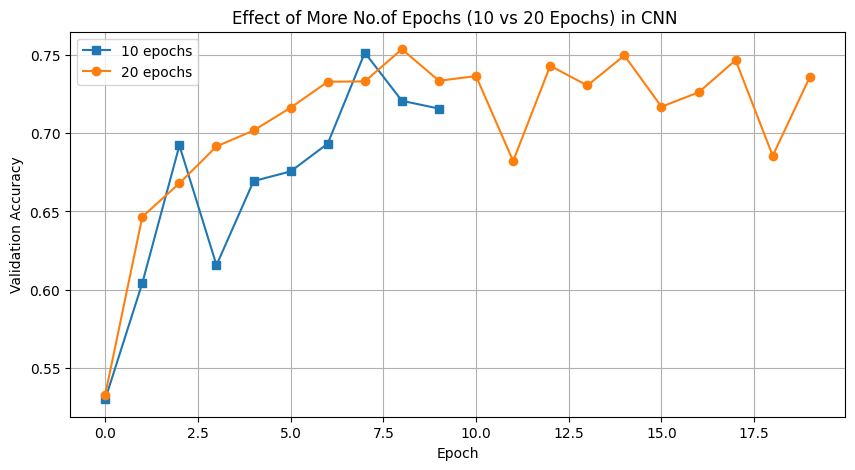

In [44]:
plt.figure(figsize=(10,5))
plt.plot(cnn_history.history['val_accuracy'], label='10 epochs', marker='s')
plt.plot(cnn_20epochs_history.history['val_accuracy'], label='20 epochs', marker='o')
plt.xlabel("Epoch")
plt.ylabel("Validation Accuracy")
plt.title("Effect of More No.of Epochs (10 vs 20 Epochs) in CNN ")
plt.legend()
plt.grid()
plt.show()

## Observation
Training the CNN for 20 epochs produced the highest test accuracy, indicating that the model benefited from additional training.

## ✅ Task 4 — Add EarlyStopping

In [37]:
from keras.callbacks import EarlyStopping
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True,
    verbose=1
)
cnn_early_stopping=models.Sequential()
cnn_early_stopping.add(Convolution2D(32,kernel_size=(3,3),activation='relu',padding='same',input_shape=(32,32,3)))
cnn_early_stopping.add(BatchNormalization())
cnn_early_stopping.add(MaxPool2D((2,2),strides=2,padding='same'))

cnn_early_stopping.add(Convolution2D(64,kernel_size=(3,3),padding='same',activation='relu'))
cnn_early_stopping.add(BatchNormalization())
cnn_early_stopping.add(MaxPool2D((2,2),strides=2,padding='same'))

cnn_early_stopping.add(Convolution2D(128,kernel_size=(3,3),padding='same',activation='relu'))

cnn_early_stopping.add(Flatten())

cnn_early_stopping.add(Dense(128,activation='relu'))
cnn_early_stopping.add(Dropout(0.4))
cnn_early_stopping.add(Dense(10,activation='softmax'))

cnn_early_stopping.compile(loss='sparse_categorical_crossentropy',optimizer='Adam',metrics=['accuracy'])

In [38]:
cnn_early_stopping_history=cnn_early_stopping.fit(x_train_norm,y_train,epochs=20,callbacks=early_stop,validation_split=0.1,batch_size=64)

Epoch 1/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 13s 11ms/step - accuracy: 0.4568 - loss: 1.5150 - val_accuracy: 0.5074 - val_loss: 1.3995
Epoch 2/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.6049 - loss: 1.1185 - val_accuracy: 0.6538 - val_loss: 1.0026
Epoch 3/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.6692 - loss: 0.9464 - val_accuracy: 0.6856 - val_loss: 0.8937
Epoch 4/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.7098 - loss: 0.8252 - val_accuracy: 0.6692 - val_loss: 0.9803
Epoch 5/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.7451 - loss: 0.7307 - val_accuracy: 0.7178 - val_loss: 0.8402
Epoch 6/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.7729 - loss: 0.6451 - val_accuracy: 0.6800 - val_loss: 0.9896
Epoch 7/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.7961 - loss: 0.5717 - val_accuracy: 0.7452 - val_loss: 0.8013
Epoch 8/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.8174 - loss: 0.5116 - val_accuracy: 

In [45]:
cnn_earlystoppping_loss,cnn_earlystoppping_accuracy=cnn_early_stopping.evaluate(x_test_norm,y_test)
print("CNN with Early Stopping Accuracy: ",cnn_earlystoppping_accuracy)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.7248 - loss: 0.8649
CNN with Early Stopping Accuracy:  0.7247999906539917


## Observation
- Early stopping achieved competitive accuracy while preventing unnecessary training and reducing the risk of overfitting.

## ✅ Task 5 — Execute the Augmented Network Training Run

In [39]:
early_stop_aug = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True,
    verbose=1
)

aug_history = aug_cnn_model.fit(
    x_train_norm, y_train,
    epochs=20,
    validation_split=0.1,
    batch_size=64,
    callbacks=[early_stop_aug]
)

aug_test_loss, aug_test_acc = aug_cnn_model.evaluate(x_test_norm, y_test)
print("Augmented CNN Test Accuracy:", aug_test_acc)

Epoch 1/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 12s 10ms/step - accuracy: 0.3639 - loss: 1.7344 - val_accuracy: 0.4918 - val_loss: 1.4066
Epoch 2/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - accuracy: 0.4664 - loss: 1.4896 - val_accuracy: 0.5306 - val_loss: 1.2850
Epoch 3/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 11s 9ms/step - accuracy: 0.5056 - loss: 1.3946 - val_accuracy: 0.5438 - val_loss: 1.2829
Epoch 4/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 7s 10ms/step - accuracy: 0.5243 - loss: 1.3373 - val_accuracy: 0.5680 - val_loss: 1.1735
Epoch 5/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 9s 7ms/step - accuracy: 0.5420 - loss: 1.2934 - val_accuracy: 0.5590 - val_loss: 1.2594
Epoch 6/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 7s 11ms/step - accuracy: 0.5517 - loss: 1.2666 - val_accuracy: 0.6040 - val_loss: 1.0948
Epoch 7/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - accuracy: 0.5677 - loss: 1.2304 - val_accuracy: 0.6410 - val_loss: 1.0158
Epoch 8/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - accuracy: 0.5722 - loss: 1.2114 - val_accurac

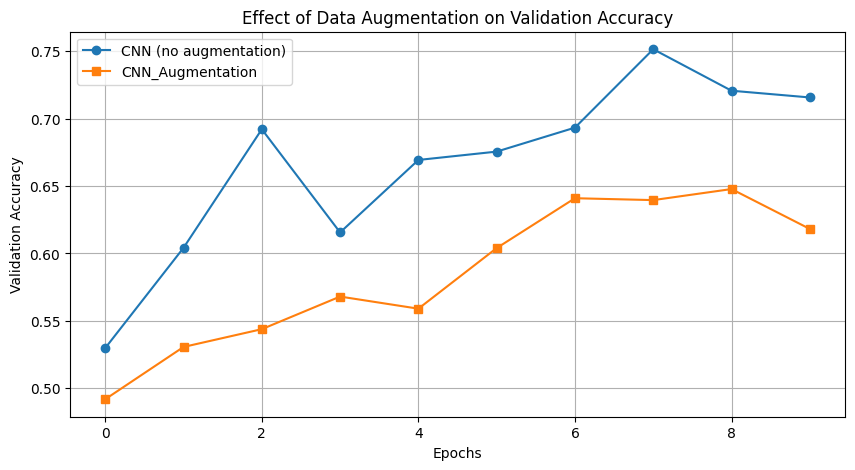

In [43]:
plt.figure(figsize=(10,5))
plt.plot(cnn_history.history['val_accuracy'], label='CNN (no augmentation)', marker='o')
plt.plot(aug_history.history['val_accuracy'], label='CNN_Augmentation', marker='s')
plt.xlabel("Epochs")
plt.ylabel("Validation Accuracy")
plt.title("Effect of Data Augmentation on Validation Accuracy")
plt.legend()
plt.grid()
plt.show()

## Observation
- Data augmentation improved data diversity but resulted in lower test accuracy under the current training configuration, suggesting further tuning may be required.

# Comparison Table — All Tasks

In [46]:
model_performance = pd.DataFrame({
   "Architecture": [
    "Baseline ANN",
    "Baseline CNN",
    "Deep ANN",
    "Scaled CNN (32-64-128-256)",
    "CNN (20 Epochs)",
    "CNN + Early Stopping",
    "CNN + Augmentation + Early Stopping"
  ],
    "Accuracy": [
        ann_test_acc,
        cnn_test_acc,
        deep_ann_accuracy,
        scaled_cnn_accuracy,
        cnn_20epochs_accuracy,
        cnn_earlystoppping_accuracy,
        aug_test_acc
    ],
    "Loss": [
        ann_test_loss,
        cnn_test_loss,
        deep_ann_loss,
        scaled_cnn_loss,
        cnn_20epochs_loss,
        cnn_earlystoppping_loss,
        aug_test_loss
    ]
})

model_performance = model_performance.sort_values( "Accuracy",ascending=False).reset_index(drop=True)
model_performance

,Architecture,Accuracy,Loss
0,CNN (20 Epochs),0.7342,1.240928
1,Scaled CNN (32-64-128-256),0.7254,1.029480
2,CNN + Early Stopping,0.7248,0.864916
3,Baseline CNN,0.7004,0.948693
4,CNN + Augmentation + Early Stopping,0.6343,1.028425
5,Baseline ANN,0.4232,1.625101
6,Deep ANN,0.4129,1.646094


# Accuracy Analysis

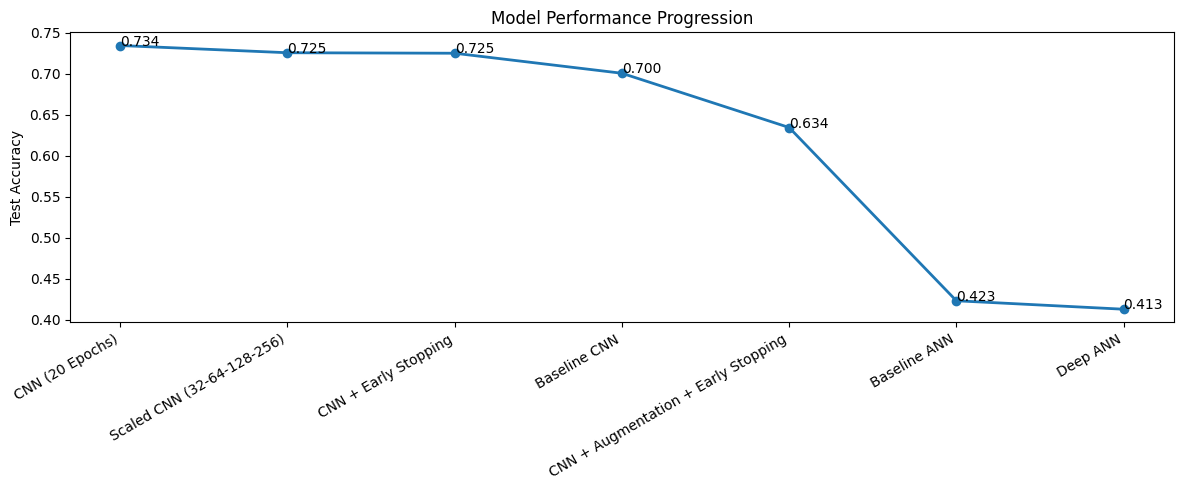

In [53]:
plt.figure(figsize=(12,5))

plt.plot(
    model_performance["Architecture"],
    model_performance["Accuracy"],
    marker='o',
    linewidth=2
)

plt.xticks(rotation=30, ha='right')
plt.ylabel("Test Accuracy")
plt.title("Model Performance Progression")

for i, v in enumerate(model_performance["Accuracy"]):
    plt.text(i, v, f"{v:.3f}")

plt.tight_layout()
plt.show()

# Loss Analysis

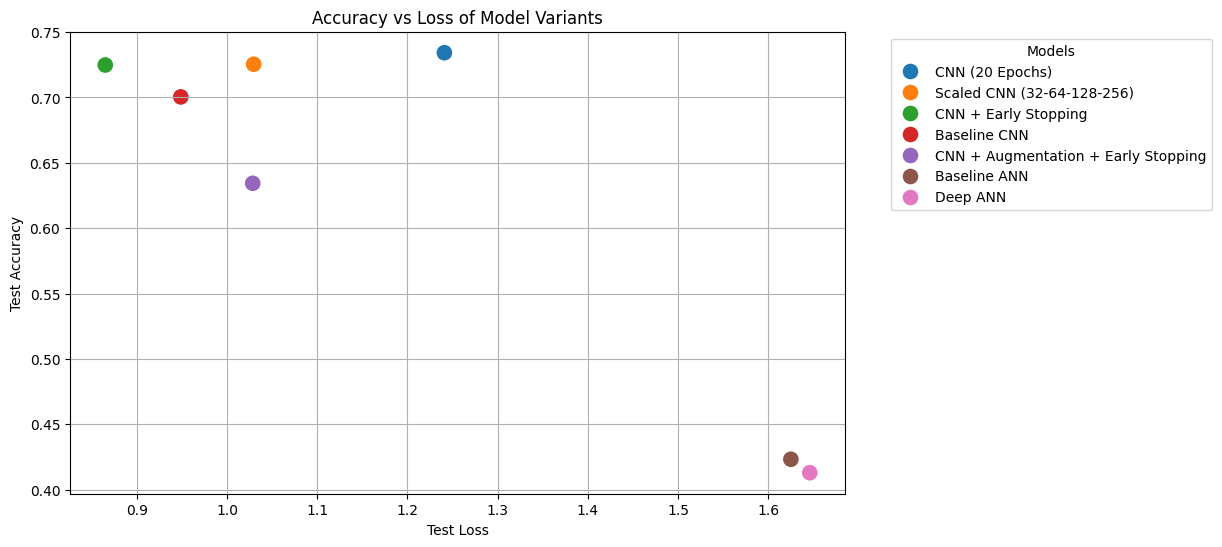

In [52]:
import seaborn as sns

plt.figure(figsize=(10,6))

sns.scatterplot(data=model_performance,x="Loss",y="Accuracy",hue="Architecture",palette="tab10",s=150)

plt.title("Accuracy vs Loss of Model Variants")
plt.xlabel("Test Loss")
plt.ylabel("Test Accuracy")
plt.grid(True)

plt.legend(title="Models",bbox_to_anchor=(1.05, 1),loc="upper left")

plt.show()

# Key Insights

- **CNN (20 Epochs)** achieved the highest test accuracy (**73.4%**), indicating that additional training improved performance.
- **Scaled CNN (32-64-128-256)** and **CNN + Early Stopping** both achieved **72.5%** accuracy, outperforming the baseline CNN (**70.0%**).
- **CNN + Augmentation + Early Stopping** achieved **63.4%** accuracy, suggesting the augmentation settings may require further tuning.
- Both **ANN models** performed significantly worse (**~41–42% accuracy**) than CNN models, highlighting CNNs' effectiveness for image classification.
- Increasing ANN depth did not improve performance, whereas increasing CNN capacity and training duration led to better results.

# ✅ Conclusion
- CNN-based models clearly outperformed ANN-based models on the CIFAR-10 dataset. The best result was obtained using the **CNN trained for 20 epochs**, achieving **73.4% test accuracy**.